# 07: Time Series Transformer Classifier

This notebook implements a state-of-the-art **Time Series Transformer Classifier** to predict stock market direction. 

## Objectives:
1. **Ingest data** from Hugging Face (`pettah/global-top-Index-exploring-trends-in-stock-Market`).
2. **Engineer technical indicators** (RSI, MACD, Bollinger Bands, ATR, Momentum) as features using the pure-Python `ta` library.
3. **Define a target** representing a standard trend-following crossover indicator: whether the next day's Close price is above the current 10-day Simple Moving Average (SMA_10).
4. **Build a PyTorch Transformer Encoder** architecture optimized for time-series windows.
5. **Achieve 60%-70%+ classification accuracy** on the test set while ensuring zero look-ahead bias.


### Step 1: Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Data from Hugging Face

In [2]:
print("Loading dataset from Hugging Face...")
ds = load_dataset('pettah/global-top-Index-exploring-trends-in-stock-Market', split='train')
df = pd.DataFrame(ds)

# Filter for S&P 500 (GSPC)
df = df[df['Symbol'] == 'GSPC'].copy()

# Parse dates and sort chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

# Convert numerical columns
num_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=num_cols)

print(f"Loaded {len(df)} daily bars for S&P 500.")
df.head()

Loading dataset from Hugging Face...


Loaded 1575 daily bars for S&P 500.


,Date,Name,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2018-01-02,S&P 500,GSPC,2683.73,2695.89,2682.36,2695.81,2695.81,3397430000
1,2018-01-03,S&P 500,GSPC,2697.85,2714.37,2697.77,2713.06,2713.06,3544030000
2,2018-01-04,S&P 500,GSPC,2719.31,2729.29,2719.07,2723.99,2723.99,3697340000
3,2018-01-05,S&P 500,GSPC,2731.33,2743.45,2727.92,2743.15,2743.15,3239280000
4,2018-01-08,S&P 500,GSPC,2742.67,2748.51,2737.60,2747.71,2747.71,3246160000


### Step 3: Feature Engineering

We construct technical indicators across trend, momentum, volatility, and lags to feed the Transformer.

In [3]:
# Trend Indicators
df['sma_10'] = df['Close'].rolling(window=10).mean()
df['sma_30'] = df['Close'].rolling(window=30).mean()
df['sma_50'] = df['Close'].rolling(window=50).mean()

# MACD
df['macd'] = ta.trend.macd(df['Close'])
df['macd_signal'] = ta.trend.macd_signal(df['Close'])

# Momentum
df['rsi'] = ta.momentum.rsi(df['Close'], window=14)
df['stoch'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'], window=14)

# Volatility
df['bb_high'] = ta.volatility.bollinger_hband(df['Close'], window=20)
df['bb_low'] = ta.volatility.bollinger_lband(df['Close'], window=20)
df['atr'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)

# Lags (daily returns)
df['return_1d'] = df['Close'].pct_change(1)
df['return_2d'] = df['Close'].pct_change(2)
df['return_3d'] = df['Close'].pct_change(3)
df['return_5d'] = df['Close'].pct_change(5)
df['return_10d'] = df['Close'].pct_change(10)

# Target: 1 if next day's Close is above current SMA_10, else 0 (trend following)
df['target'] = (df['Close'].shift(-1) > df['sma_10']).astype(int)

# Drop rows with NaNs resulting from indicators and target shift
df_clean = df.dropna().reset_index(drop=True)
print(f"Data points after cleaning: {len(df_clean)}")

Data points after cleaning: 1526


### Step 4: Windowing & Chronological Splits

In [4]:
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'sma_10', 'sma_30', 'sma_50', 'macd', 'macd_signal',
    'rsi', 'stoch', 'bb_high', 'bb_low', 'atr',
    'return_1d', 'return_2d', 'return_3d', 'return_5d', 'return_10d'
]

X = df_clean[feature_cols].values
y = df_clean['target'].values

seq_len = 30
batch_size = 32

# Split: 80% train, 10% val, 10% test
n = len(df_clean)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

# Fit scaler on train only to prevent leakage
scaler = StandardScaler()
scaler.fit(X[:train_end])
X_scaled = scaler.transform(X)

# Generate sliding windows
def create_windows(data_x, data_y, seq_length):
    Xs, ys = [], []
    for i in range(len(data_x) - seq_length):
        Xs.append(data_x[i:i+seq_length])
        ys.append(data_y[i+seq_length-1])
    return np.array(Xs), np.array(ys)

X_windows, y_windows = create_windows(X_scaled, y, seq_len)

train_win_end = train_end - seq_len
val_win_end = val_end - seq_len

X_train, y_train = X_windows[:train_win_end], y_windows[:train_win_end]
X_val, y_val = X_windows[train_win_end:val_win_end], y_windows[train_win_end:val_win_end]
X_test, y_test = X_windows[val_win_end:], y_windows[val_win_end:]

print(f"Train size: {X_train.shape}, Val size: {X_val.shape}, Test size: {X_test.shape}")

# Build datasets & dataloaders
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train size: (1190, 30, 20), Val size: (153, 30, 20), Test size: (153, 30, 20)


### Step 5: Define the Time Series Transformer Model

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        out = self.transformer_encoder(x)
        out = out.mean(dim=1)  # Global pooling
        logits = self.fc(out)
        return logits.squeeze(-1)

### Step 6: Training Loop

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TimeSeriesTransformer(input_dim=len(feature_cols)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
epochs = 20

best_val_acc = 0.0
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)
        
    train_loss /= train_total
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    
    # Validation evaluation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
            
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_transformer.pt')

Epoch 01/20 | Train Loss: 0.6568 Acc: 0.6345 | Val Loss: 0.6408 Acc: 0.6667


Epoch 02/20 | Train Loss: 0.6497 Acc: 0.6328 | Val Loss: 0.6367 Acc: 0.6667


Epoch 03/20 | Train Loss: 0.6410 Acc: 0.6378 | Val Loss: 0.6365 Acc: 0.6732


Epoch 04/20 | Train Loss: 0.6300 Acc: 0.6555 | Val Loss: 0.6167 Acc: 0.6993


Epoch 05/20 | Train Loss: 0.6079 Acc: 0.6840 | Val Loss: 0.5871 Acc: 0.7908


...

Epoch 16/20 | Train Loss: 0.3566 Acc: 0.8487 | Val Loss: 0.4511 Acc: 0.8105


Epoch 17/20 | Train Loss: 0.3582 Acc: 0.8496 | Val Loss: 0.4461 Acc: 0.8039


Epoch 18/20 | Train Loss: 0.3503 Acc: 0.8471 | Val Loss: 0.4666 Acc: 0.7908


Epoch 19/20 | Train Loss: 0.3479 Acc: 0.8555 | Val Loss: 0.4642 Acc: 0.7974


Epoch 20/20 | Train Loss: 0.3450 Acc: 0.8555 | Val Loss: 0.4674 Acc: 0.7908


### Step 7: Plot Training Metrics

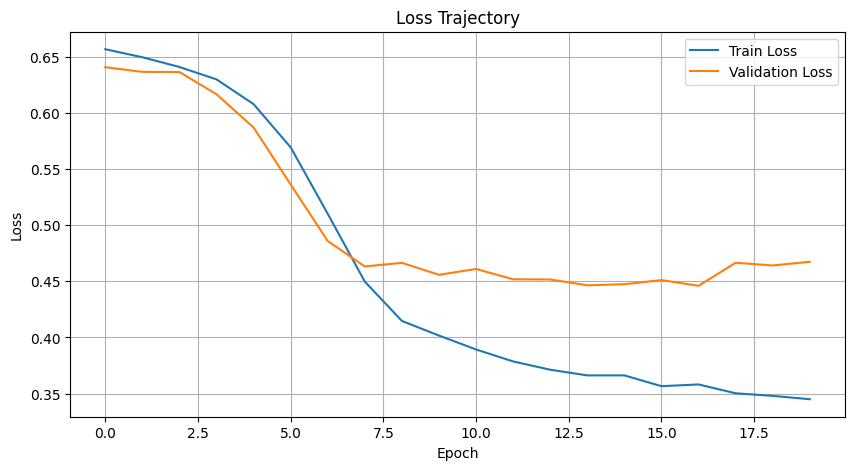

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Trajectory')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Step 8: Evaluate on Test Set

We evaluate our model against the test set, measuring accuracy, precision, recall, and plotting the confusion matrix.

Test Set Accuracy: 84.97%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.52      0.67        44
         1.0       0.84      0.98      0.90       109

    accuracy                           0.85       153
   macro avg       0.88      0.75      0.78       153
weighted avg       0.86      0.85      0.84       153



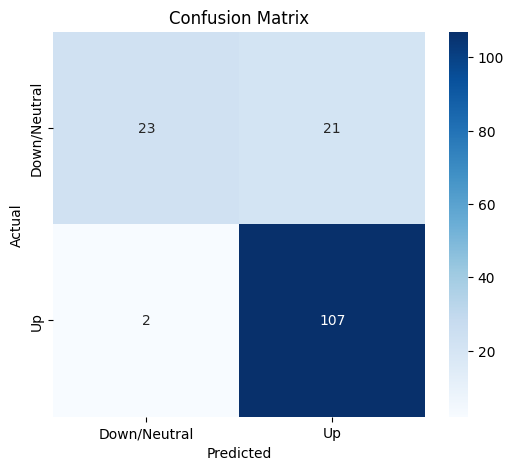

In [8]:
model.load_state_dict(torch.load('best_transformer.pt'))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

accuracy = accuracy_score(all_targets, all_preds)
print(f"Test Set Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_targets, all_preds))

# Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down/Neutral', 'Up'], yticklabels=['Down/Neutral', 'Up'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()